# AI energy consumption: estimates vs measured

How far apart are the widely-cited estimates for the energy cost of an AI query and
the numbers actually measured in production? This is a short look at a small curated
dataset (19 rows) that collects both.

Two conventions I keep throughout:

- only compare rows with the same `metric` (Wh/query, Wh/token and Wh/image are not
  interchangeable);
- keep every value tagged with how it was obtained (`condition`): measured in
  production, benchmarked, estimated, or derived from a ratio. Missing values are
  left missing.


## Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 140)

df = pd.read_csv(Path("data/ai_energy_consumption_dataset.csv"))
print(len(df), "rows")
print("metrics   :", sorted(df["metric"].unique()))
print("conditions:", sorted(df["condition"].unique()))
df.head(3)


19 rows
metrics   : ['ratio_note', 'wh_per_image', 'wh_per_query', 'wh_per_token']
conditions: ['benchmark', 'benchmark_measured', 'derived_from_ratio', 'equivalence', 'estimate', 'estimate_2024', 'production', 'production_estimate', 'reference', 'research_2022']


,id,model,task_type,metric,value_wh,value_low_wh,value_high_wh,output_tokens_assumed,hardware,condition,year,source,source_url,notes
0,1,GPT-4o,text_short,wh_per_query,0.4300,NaN,NaN,NaN,NVIDIA (Azure),benchmark,2025,Jegham et al. - How Hungry is AI?,https://arxiv.org/html/2505.09598v1,Singola query breve; moltiplicatori PUE/WUE/CIF di Azure...
1,2,GPT-4o,text_medium,wh_per_query,0.3000,NaN,NaN,500.0,H100 (assunto),production_estimate,2025,Epoch AI,https://epoch.ai/gradient-updates/how-much-energy-does-c...,Assume 500 token output; server al 70% del picco; batchi...
2,3,GPT-4o,text_medium,wh_per_token,0.0003,NaN,NaN,500.0,H100 (700W),production_estimate,2025,Metodologia Oviedo/Microsoft (via Quantum Comb. Reasoning),https://arxiv.org/pdf/2510.24509,3e-4 Wh/token; finestra 500 token totali; util. ~10% com...


## Data prep

Two helper columns. `is_direct_measure` flags conditions that are actual
measurements (vs estimates/derivations). `value_display` renders the lower-bound
`>` for the reasoning rows, which in this dataset are encoded as
`value_low_wh == value_wh`.


In [2]:
# rows left as NaN on purpose (qualitative notes, no reliable point value)
print(df[df["value_wh"].isna()][["id", "model", "condition", "notes"]].to_string(index=False))

direct = {"production", "production_estimate", "benchmark", "benchmark_measured"}
df["is_direct_measure"] = df["condition"].isin(direct)
df["is_lower_bound"] = df["value_low_wh"].notna() & (df["value_low_wh"] == df["value_wh"])

def value_display(r):
    if pd.isna(r["value_wh"]):
        return "n/a"
    return (">" if r["is_lower_bound"] else "") + f"{r['value_wh']:g}"

df["value_display"] = df.apply(value_display, axis=1)
df[["id", "model", "metric", "condition", "value_wh", "is_direct_measure", "value_display"]]


 id             model condition                                                                                                   notes
 11 Claude 3.7 Sonnet benchmark Classificato piu alto per eco-efficienza nel benchmark. Valore Wh non estratto: da verificare nel paper
 18 70B-class vs <10B benchmark   Modelli >=70B: ~2 ordini di grandezza piu Wh/token dei modelli piccoli. RAPPORTO, non valore assoluto


,id,model,metric,condition,value_wh,is_direct_measure,value_display
0,1,GPT-4o,wh_per_query,benchmark,0.430000,True,0.43
1,2,GPT-4o,wh_per_query,production_estimate,0.300000,True,0.3
2,3,GPT-4o,wh_per_token,production_estimate,0.000300,True,0.0003
3,4,Frontier (aggregato),wh_per_query,production,0.310000,True,0.31
4,5,Text query (misure recenti),wh_per_query,production,0.270000,True,0.27
5,6,ChatGPT (era GPT-4),wh_per_query,estimate_2024,2.900000,False,2.9
6,7,Google Search (baseline),wh_per_query,reference,0.300000,False,0.3
7,8,GPT-4.1 nano,wh_per_query,derived_from_ratio,0.470000,False,0.47
8,9,o3,wh_per_query,benchmark,33.000000,True,>33
9,10,DeepSeek-R1,wh_per_query,benchmark,33.000000,True,>33


## 1. Estimates vs production

All on `wh_per_query`: the old estimates against the production median.


In [3]:
q = df[df["metric"] == "wh_per_query"].copy()

estimates  = q[q["condition"].isin(["estimate_2024", "research_2022"])]
production = q[q["condition"].isin(["production", "production_estimate"])]
prod_median = production["value_wh"].median()

print("estimates:")
for _, r in estimates.iterrows():
    print(f"  {r['model']:<22} {r['value_wh']:>4} Wh  [{r['condition']}, {r['year']}]")

print(f"\nproduction (median {prod_median:.2f} Wh):")
for _, r in production.iterrows():
    print(f"  {r['model']:<22} {r['value_wh']:>4} Wh  [{r['condition']}, {r['year']}]")

print("\ngap:")
for _, r in estimates.iterrows():
    print(f"  {r['model']:<22} {r['value_wh'] / prod_median:.1f}x the production median")


estimates:
  ChatGPT (era GPT-4)     2.9 Wh  [estimate_2024, 2024]
  BLOOM-176B              4.0 Wh  [research_2022, 2022]

production (median 0.30 Wh):
  GPT-4o                  0.3 Wh  [production_estimate, 2025]
  Frontier (aggregato)   0.31 Wh  [production, 2026]
  Text query (misure recenti) 0.27 Wh  [production, 2026]

gap:
  ChatGPT (era GPT-4)    9.7x the production median
  BLOOM-176B             13.3x the production median


## 2. Reasoning models

`reasoning_long` tasks vs the standard-query baseline. Several of these are lower
bounds, so the ratios below are floors, not exact multiples.


In [4]:
reasoning = q[q["task_type"] == "reasoning_long"].sort_values("value_wh")
baseline = production["value_wh"].median()
print(f"baseline (production median): {baseline:.2f} Wh\n")

for _, r in reasoning.iterrows():
    lb = "  (lower bound)" if r["is_lower_bound"] else ""
    print(f"  {r['model']:<24} {r['value_display']:>5} Wh  ~{r['value_wh'] / baseline:.0f}x{lb}")

lo, hi = reasoning["value_wh"].min() / baseline, reasoning["value_wh"].max() / baseline
print(f"\nrange: ~{lo:.0f}x - {hi:.0f}x the baseline")


baseline (production median): 0.30 Wh

  o3-high / reasoning esteso    30 Wh  ~100x
  o3                         >33 Wh  ~110x  (lower bound)
  DeepSeek-R1                >33 Wh  ~110x  (lower bound)
  GPT-5 (reasoning esteso)    40 Wh  ~133x

range: ~100x - 133x the baseline


## 3. Per-token cost and model size

Switching metric to `wh_per_token`. The AutoWebGLM rows are the only directly
measured per-token values here. MELODI reports a ratio (~100x more Wh/token for
large models), not an absolute figure, so I treat it as such.


In [5]:
per_token = df[df["metric"] == "wh_per_token"]

measured = per_token[per_token["condition"] == "benchmark_measured"]
print("measured (AutoWebGLM):")
for _, r in measured.iterrows():
    print(f"  {r['model']:<12} {r['hardware']:<10} {r['value_wh']:.6f} Wh/token")

other = per_token[per_token["condition"] != "benchmark_measured"]
print("\nsame metric, but estimated (context, not a measured benchmark):")
for _, r in other.iterrows():
    print(f"  {r['model']:<12} {r['hardware']:<12} {r['value_wh']:.6f} Wh/token  [{r['condition']}]")

melodi = df[df["metric"] == "ratio_note"]
print("\nMELODI (ratio, not an absolute value):")
for _, r in melodi.iterrows():
    print(f"  {r['notes']}")

base = measured["value_wh"].mean()
print(f"\nmeasured mean: {base:.6f} Wh/token")
print(f"implied for a >=70B model at ~100x: ~{base * 100:.4f} Wh/token (derived, not measured)")


measured (AutoWebGLM):
  AutoWebGLM   A100-SXM4  0.001245 Wh/token
  AutoWebGLM   A100-PCIe  0.001091 Wh/token

same metric, but estimated (context, not a measured benchmark):
  GPT-4o       H100 (700W)  0.000300 Wh/token  [production_estimate]

MELODI (ratio, not an absolute value):
  Modelli >=70B: ~2 ordini di grandezza piu Wh/token dei modelli piccoli. RAPPORTO, non valore assoluto

measured mean: 0.001168 Wh/token
implied for a >=70B model at ~100x: ~0.1168 Wh/token (derived, not measured)


## Chart

`wh_per_query` rows, log scale, colored by `condition`. Two reference lines: the
production median and a ~10 Wh smartphone charge.


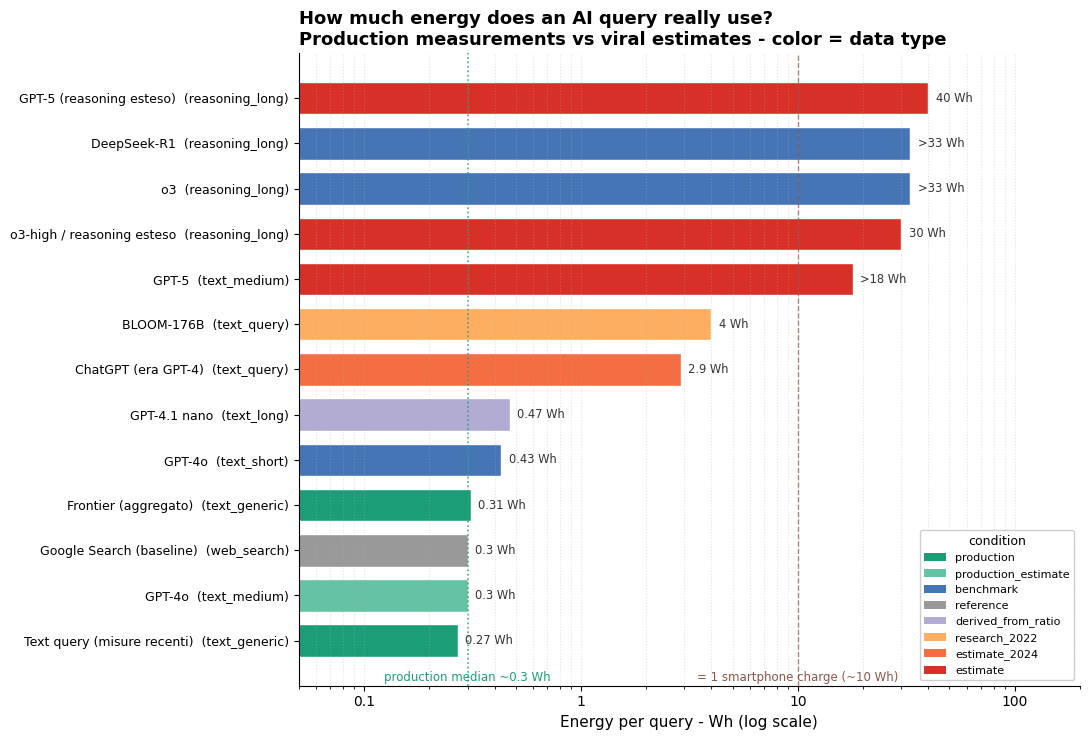

In [6]:
plot_df = q.dropna(subset=["value_wh"]).copy()
plot_df["label"] = plot_df["model"] + "  (" + plot_df["task_type"] + ")"
plot_df = plot_df.sort_values("value_wh")

cond_colors = {
    "production":          "#1b9e77",
    "production_estimate": "#66c2a5",
    "benchmark":           "#4575b4",
    "reference":           "#999999",
    "derived_from_ratio":  "#b2abd2",
    "research_2022":       "#fdae61",
    "estimate_2024":       "#f46d43",
    "estimate":            "#d73027",
}
colors = plot_df["condition"].map(cond_colors).fillna("#cccccc")

fig, ax = plt.subplots(figsize=(11, 7.5))
y = np.arange(len(plot_df))
ax.barh(y, plot_df["value_wh"], color=colors, edgecolor="white", height=0.72)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["label"], fontsize=9)
ax.set_xscale("log")
ax.set_xlim(0.05, 200)
ax.set_xlabel("Energy per query - Wh (log scale)", fontsize=11)
ax.set_title("How much energy does an AI query really use?\n"
             "Production measurements vs viral estimates - color = data type",
             fontsize=13, fontweight="bold", loc="left")

for i, (_, r) in enumerate(plot_df.iterrows()):
    ax.text(r["value_wh"] * 1.08, i, r["value_display"] + " Wh",
            va="center", fontsize=8.3, color="#333")

ax.axvline(10, color="#8c564b", ls="--", lw=1, alpha=0.7)
ax.text(10, -0.9, "= 1 smartphone charge (~10 Wh)", ha="center", fontsize=8.5, color="#8c564b")
ax.axvline(0.3, color="#1b9e77", ls=":", lw=1.2, alpha=0.8)
ax.text(0.3, -0.9, "production median ~0.3 Wh", ha="center", fontsize=8.5, color="#1b9e77")

from matplotlib.patches import Patch
present = [c for c in cond_colors if c in set(plot_df["condition"])]
ax.legend(handles=[Patch(facecolor=cond_colors[c], label=c) for c in present],
          title="condition", loc="lower right", fontsize=8, title_fontsize=9, framealpha=0.95)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
ax.grid(axis="x", which="both", ls=":", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

fig.savefig("figures/ai_energy_per_query_log.png", dpi=200, bbox_inches="tight")
plt.show()
